In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/student-mat.csv', sep=';')

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))


/content/drive/MyDrive/student-mat.csv
/content/drive/MyDrive/Saved from Chrome/customcert-report.csv


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/student-mat.csv', sep=';')
print(df.shape)
print(df.head())


(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [ ]:

print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nTarget distribution:\n", df['G3'].value_counts().sort_index())

Missing values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Data types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher  

In [ ]:

df['pass'] = (df['G3'] >= 10).astype(int)
print("Pass vs Fail:\n", df['pass'].value_counts())

Pass vs Fail:
 pass
1    265
0    130
Name: count, dtype: int64


/tmp/ipykernel_6488/978803741.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')


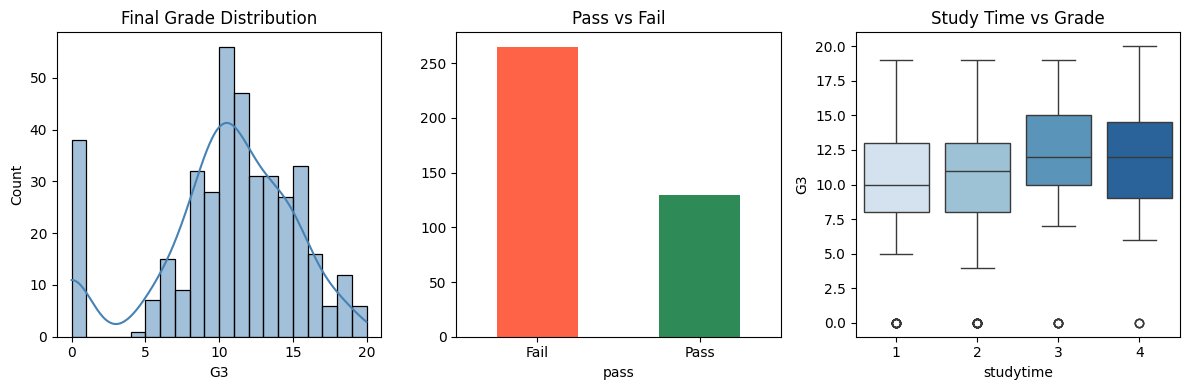

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['G3'], bins=20, color='steelblue', kde=True)
plt.title('Final Grade Distribution')

plt.subplot(1, 3, 2)
df['pass'].value_counts().plot(kind='bar', color=['tomato', 'seagreen'])
plt.title('Pass vs Fail')
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)

plt.subplot(1, 3, 3)
sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')
plt.title('Study Time vs Grade')

plt.tight_layout()
plt.show()

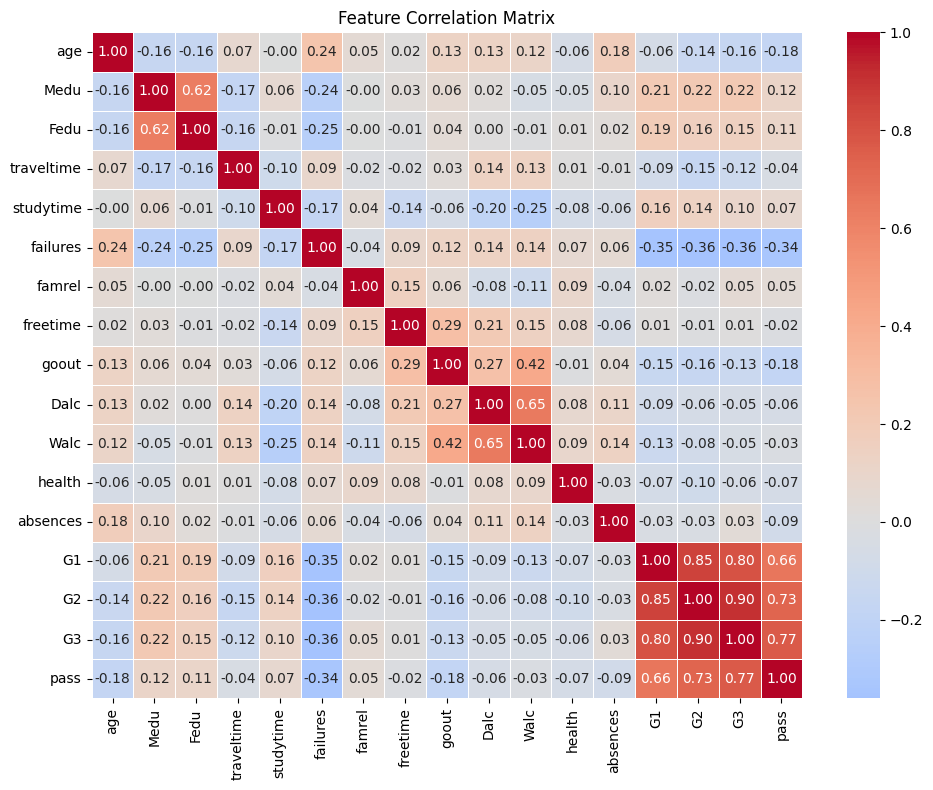

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

features = ['studytime','absences','failures','G1','G2',
            'Medu','Fedu','sex','address','internet','goout','health']
X = df[features]
y = df['pass']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("✅ Preprocessing done!")

Train: (316, 12), Test: (79, 12)
✅ Preprocessing done!


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_s, y_train)
knn_pred = knn_model.predict(X_test_s)


dt_acc  = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print(f"Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print(f"KNN Accuracy:           {knn_acc * 100:.2f}%")

Decision Tree Accuracy: 88.61%
KNN Accuracy:           81.01%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("── Decision Tree ─────────────────────────")
print(classification_report(y_test, dt_pred, target_names=['Fail', 'Pass']))

print("── KNN ───────────────────────────────────")
print(classification_report(y_test, knn_pred, target_names=['Fail', 'Pass']))


── Decision Tree ─────────────────────────
              precision    recall  f1-score   support

        Fail       0.85      0.81      0.83        27
        Pass       0.91      0.92      0.91        52

    accuracy                           0.89        79
   macro avg       0.88      0.87      0.87        79
weighted avg       0.89      0.89      0.89        79

── KNN ───────────────────────────────────
              precision    recall  f1-score   support

        Fail       0.77      0.63      0.69        27
        Pass       0.82      0.90      0.86        52

    accuracy                           0.81        79
   macro avg       0.80      0.77      0.78        79
weighted avg       0.81      0.81      0.80        79



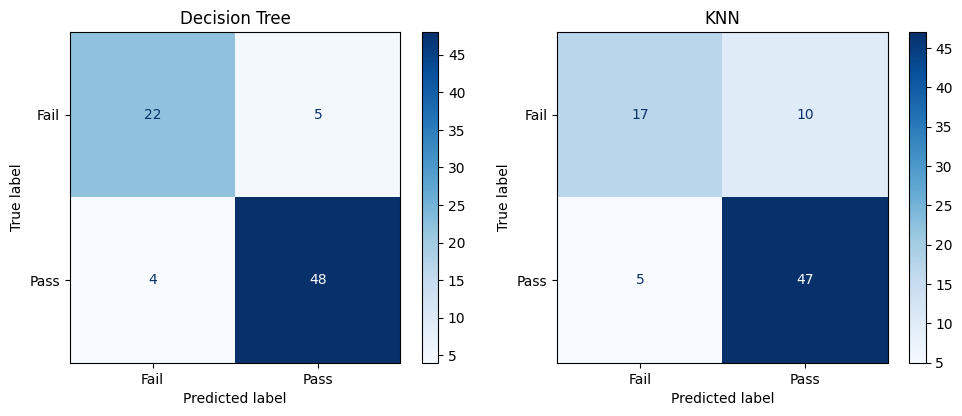

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in zip(axes, [dt_pred, knn_pred], ['Decision Tree', 'KNN']):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass']).plot(ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6488/3115660356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Blues_r')


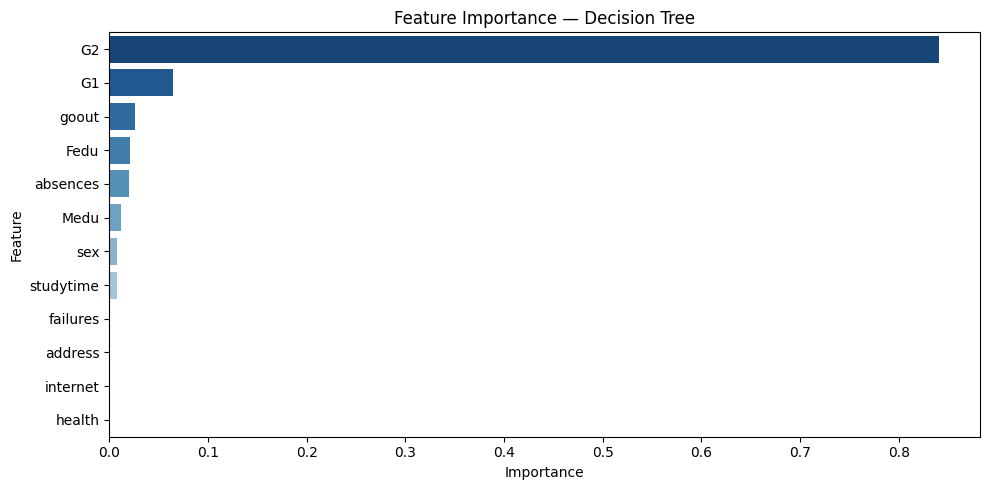

In [ ]:
importances = dt_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Blues_r')
plt.title('Feature Importance — Decision Tree')
plt.tight_layout()
plt.show()

               Accuracy  Precision  Recall  F1 Score
Decision Tree      0.89       0.91    0.92      0.91
KNN                0.81       0.82    0.90      0.86


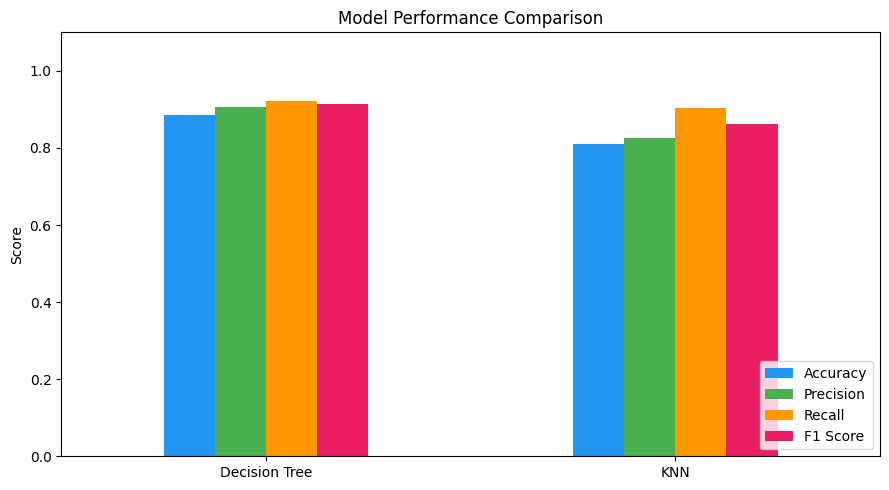

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results_df = pd.DataFrame({
    'Accuracy':  [dt_acc, knn_acc],
    'Precision': [precision_score(y_test, dt_pred),
                  precision_score(y_test, knn_pred)],
    'Recall':    [recall_score(y_test, dt_pred),
                  recall_score(y_test, knn_pred)],
    'F1 Score':  [f1_score(y_test, dt_pred),
                  f1_score(y_test, knn_pred)]
}, index=['Decision Tree', 'KNN'])

print(results_df.round(2))

results_df.plot(kind='bar', figsize=(9, 5),
    color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()